# Predicting land cover changes in Volcanoes National Park, Rwanda

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import geopandas as gpd
import rasterio
from scipy.ndimage import zoom
from matplotlib.patches import Patch
from rasterio.warp import reproject, Resampling
from scipy.stats import multinomial
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, cohen_kappa_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os
import warnings
from scipy.stats import multinomial
from statsmodels.tools.tools import add_constant
import time

In [2]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [3]:
# Paths to input raster files
path_2019 = "./classified_maps/VNP_landcover_2019.tif"
path_2024 = "./classified_maps/VNP_landcover_2024.tif"
path_elevation = "./drivers/vnp_elevation.tif"
path_slope = "./drivers/vnp_slope.tif"
bioclim_2040 = "./clipped_masked_bioclim/selected_var/wc2.1_30s_bioc_BCC-CSM2-MR_ssp126_2021-2040_selected_variable_vif3.tif"
bioclim_2060 = "./clipped_masked_bioclim/selected_var/wc2.1_30s_bioc_BCC-CSM2-MR_ssp126_2041-2060_selected_variable_vif3.tif"
output_directory = "./predicted_results"

### Load the data

In [4]:
def load_image(file_path, load_all_bands=False):
    try:
        with rasterio.open(file_path) as src:
            if load_all_bands:
                raster_data = src.read() 
            else:
                raster_data = src.read(1) 

            metadata = src.meta
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

            return raster_data, metadata, extent

    except Exception as e:
        print(f"Error loading raster file: {file_path}")
        raise e

In [5]:
# Load land cover maps
landcover_2019, meta_2019, extent_2019 = load_image(path_2019)
landcover_2024, meta_2024, extent_2024 = load_image(path_2024)

In [6]:
print(landcover_2019.shape)

(2384, 3750)


In [7]:
# Load other datasets
elevation, meta_elevation, extent_elevation = load_image(path_elevation)
slope, meta_slope, extent_slope = load_image(path_slope)

In [8]:
print(slope.shape)

(2384, 3750)


In [9]:
# Load multi-band bioclim datasets
bioclim_2040, meta_bioclim_2040, extent_bioclim_2040 = load_image(bioclim_2040, load_all_bands=True)
bioclim_2060, meta_bioclim_2060, extent_bioclim_2060 = load_image(bioclim_2060, load_all_bands=True)

In [10]:
print(bioclim_2040.shape)
print(bioclim_2060.shape)

(4, 2384, 3750)
(4, 2384, 3750)


In [11]:
# Define class labels
class_labels = ["Bamboo", "Mixed forest", "Hagenia-Hypericum", "Herbaceous", "Subalpine", "Alpine", "Water", "Bare", "Meadow"]

In [12]:
def visualize_raster(raster, title, class_labels, extent):
    # Mask class 0 (if background) for better visualization
    raster = np.where(raster == 0, np.nan, raster)

    # Define color map for land cover classes
    colors = ["yellow", "darkgreen", "paleturquoise", "aqua", "goldenrod", 
              "dimgrey", "blue", "red", "mediumorchid"]
    cmap = ListedColormap(colors[:len(class_labels)])  
    bounds = np.arange(0.5, len(class_labels) + 1.5)   
    norm = BoundaryNorm(bounds, cmap.N)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Display raster with correct extent
    img = ax.imshow(raster, cmap=cmap, norm=norm, origin='upper', extent=extent)

    # Dynamically set tick marks based on raster size
    num_ticks = 5  
    xticks = np.linspace(extent[0], extent[1], num_ticks)
    yticks = np.linspace(extent[2], extent[3], num_ticks)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    # Add labels and gridlines
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(color="black", linestyle="--", linewidth=0.5)

    # Ensure correct aspect ratio (prevents stretching)
    ax.set_aspect('equal')

    # Create a custom legend
    legend_patches = [Patch(color=colors[i], label=class_labels[i]) for i in range(len(class_labels))]
    ax.legend(handles=legend_patches, title="Land Cover Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set title and adjust layout
    ax.set_title(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    plt.show()

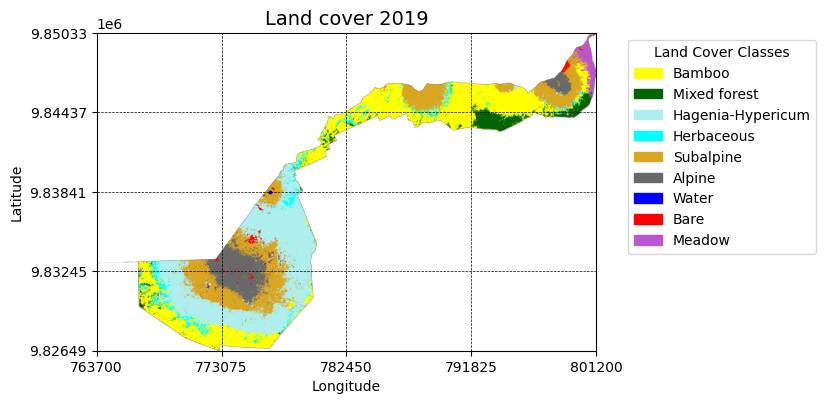

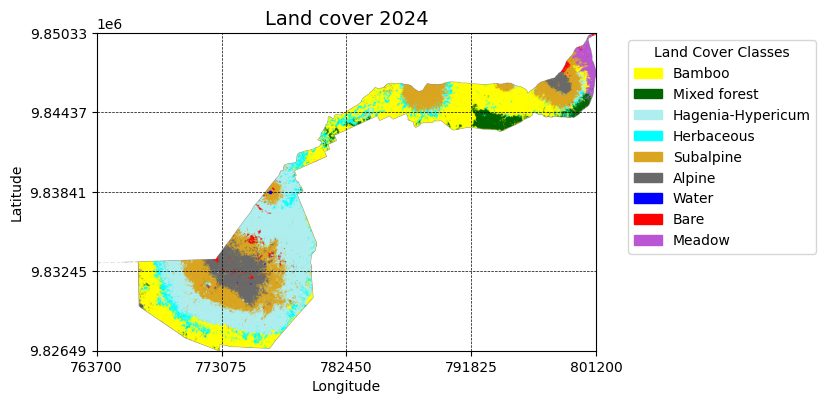

In [13]:
visualize_raster(landcover_2019, "Land cover 2019", class_labels, extent_2019)
visualize_raster(landcover_2024, "Land cover 2024", class_labels, extent_2024)

### Estimating the year-specific bioclim data 

In [14]:
def interpolate_bioclim(bioclim_2040, bioclim_2060, target_year, start_year=2021, end_year=2060):
    # Calculate weights based on proximity
    weight_2040 = (end_year - target_year) / (end_year - start_year)
    weight_2060 = 1 - weight_2040
    
    # Perform a weighted linear interpolation
    return weight_2040 * bioclim_2040 + weight_2060 * bioclim_2060

In [15]:
# Static drivers
static_drivers = [slope, elevation]

In [16]:
# Dynamic drivers: Interpolate for target years
bioclim_2024 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2024)
bioclim_2029 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2029)
bioclim_2034 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2034)
bioclim_2039 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2039)
bioclim_2044 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2044)
bioclim_2049 = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=2049)

### Save the interpolated bioclim images 

In [17]:
# def save_bioclim(output_path, raster_stack, meta):
#     meta = meta.copy()
#     meta.update(dtype='float32', count=raster_stack.shape[0], nodata=np.nan) 

#     with rasterio.open(output_path, 'w', **meta) as dst:
#         dst.write(raster_stack.astype('float32')) 

In [18]:
# for year in [2024, 2029, 2034, 2039, 2044, 2049]:
#     raster_stack = interpolate_bioclim(bioclim_2040, bioclim_2060, target_year=year)

#     # Save the multi-band Bioclim raster
#     save_bioclim(os.path.join(output_directory, f"bioclim_{year}.tif"), raster_stack, meta_bioclim_2040)

### Preparing the data for training 

In [19]:
def prepare_data(landcover, target, static_drivers, dynamic_drivers, window_size=4):
    rows, cols = landcover.shape
    pad_size = window_size
    padded_landcover = np.pad(landcover, pad_size, mode='reflect')

    static_drivers = np.array(static_drivers)  # Shape: (num_static, rows, cols)
    dynamic_drivers = np.array(dynamic_drivers)  # Shape: (num_dynamic, rows, cols)

    windows = []
    static_values_list = []
    dynamic_values_list = []
    targets = []

    for i in range(rows):
        for j in range(cols):
            if landcover[i, j] == 0 or target[i, j] == 0:
                continue
            if np.any(np.isnan(dynamic_drivers[:, i, j])) or np.any(np.isnan(static_drivers[:, i, j])):
                continue

            window = padded_landcover[i:i + 2*window_size + 1, j:j + 2*window_size + 1]
            window = window.reshape(1, 2*window_size + 1, 2*window_size + 1)

            static_values = static_drivers[:, i, j]
            dynamic_values = dynamic_drivers[:, i, j]

            windows.append(window)
            static_values_list.append(static_values)
            dynamic_values_list.append(dynamic_values)
            targets.append(target[i, j])

    return np.array(windows), np.array(static_values_list), np.array(dynamic_values_list), np.array(targets)

In [21]:
# Prepare training data
windows, static_values, dynamic_values, targets = prepare_data(landcover_2019, landcover_2024, static_drivers, bioclim_2024)

In [22]:
# Save original labels for class weight calculation
original_targets = targets.copy()

In [23]:
# Ensure labels are 0-indexed
targets = targets - 1

In [24]:
# Create combined driver features
driver_features = np.concatenate([static_values, dynamic_values], axis=1)

In [25]:
# Scale the driver features
scaler = StandardScaler()
scaled_drivers = scaler.fit_transform(driver_features)

In [26]:
# Split data
indices = np.arange(len(targets))
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)

In [27]:
print(f"Number of training samples: {len(train_indices)}")
print(f"Number of testing samples: {len(test_indices)}")

Number of training samples: 1285144
Number of testing samples: 321286


In [28]:
train_targets = targets[train_indices]
test_targets = targets[test_indices]

In [29]:
classes, train_counts = np.unique(train_targets, return_counts=True)
print(dict(zip(classes, train_counts)))

{np.int32(0): np.int64(366509), np.int32(1): np.int64(53368), np.int32(2): np.int64(369316), np.int32(3): np.int64(94977), np.int32(4): np.int64(245802), np.int32(5): np.int64(116446), np.int32(6): np.int64(869), np.int32(7): np.int64(10526), np.int32(8): np.int64(27331)}


In [30]:
pd.DataFrame({'class': classes + 1, 'n_samples': train_counts, 'percentage': (train_counts / train_counts.sum() * 100).round(2)})

,class,n_samples,percentage
0,1,366509,28.52
1,2,53368,4.15
2,3,369316,28.74
3,4,94977,7.39
4,5,245802,19.13
5,6,116446,9.06
6,7,869,0.07
7,8,10526,0.82
8,9,27331,2.13


In [31]:
classes, test_counts = np.unique(test_targets, return_counts=True)
print(dict(zip(classes, test_counts)))

{np.int32(0): np.int64(91198), np.int32(1): np.int64(13315), np.int32(2): np.int64(92901), np.int32(3): np.int64(23746), np.int32(4): np.int64(61406), np.int32(5): np.int64(29085), np.int32(6): np.int64(213), np.int32(7): np.int64(2550), np.int32(8): np.int64(6872)}


In [32]:
pd.DataFrame({'class': classes + 1, 'n_samples': test_counts, 'percentage': (test_counts / test_counts.sum() * 100).round(2)})

,class,n_samples,percentage
0,1,91198,28.39
1,2,13315,4.14
2,3,92901,28.92
3,4,23746,7.39
4,5,61406,19.11
5,6,29085,9.05
6,7,213,0.07
7,8,2550,0.79
8,9,6872,2.14


In [33]:
train_windows = windows[train_indices]
train_drivers = scaled_drivers[train_indices]
train_targets = targets[train_indices]

In [34]:
test_windows = windows[test_indices]
test_drivers = scaled_drivers[test_indices]
test_targets = targets[test_indices]

In [35]:
# Convert to PyTorch tensors
train_windows_tensor = torch.FloatTensor(train_windows)
train_drivers_tensor = torch.FloatTensor(train_drivers)
train_targets_tensor = torch.LongTensor(train_targets)

test_windows_tensor = torch.FloatTensor(test_windows)
test_drivers_tensor = torch.FloatTensor(test_drivers)
test_targets_tensor = torch.LongTensor(test_targets)

### Create DataLoaders

In [36]:
batch_size = 64
train_dataset = TensorDataset(train_windows_tensor, train_drivers_tensor, train_targets_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_windows_tensor, test_drivers_tensor, test_targets_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

### Define the model

In [37]:
class HybridCNN(nn.Module):
    def __init__(self, window_size=4, driver_features=driver_features.shape[1], num_classes=9):
        super(HybridCNN, self).__init__()

        self.input_size = 2 * window_size + 1

        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=0)
        self.deconv2 = nn.ConvTranspose2d(32, 16, kernel_size=5, stride=1, padding=0)

        # Driver features processing
        self.fc_drivers1 = nn.Linear(driver_features, 8)
        self.bn_drivers1 = nn.BatchNorm1d(8)
        self.fc_drivers2 = nn.Linear(8, 16)
        self.bn_drivers2 = nn.BatchNorm1d(16)
        self.fc_drivers3 = nn.Linear(16, 32)
        self.bn_drivers3 = nn.BatchNorm1d(32)
        self.fc_drivers4 = nn.Linear(32, 64)
        self.bn_drivers4 = nn.BatchNorm1d(64) 

        # Flattened CNN feature size
        flattened_size = 16 * self.input_size * self.input_size
        combined_features = flattened_size + 64

        # Final classifier
        self.fc1 = nn.Linear(combined_features, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.6)

    def forward(self, window, drivers):
        x = self.pool1(F.leaky_relu(self.bn1(self.conv1(window)), negative_slope=0.1))
        x = self.pool2(F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.1))
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.1)
        x = F.leaky_relu(self.bn4(self.conv4(x)), negative_slope=0.1)

        x = F.leaky_relu(self.deconv1(x), negative_slope=0.1)
        x = F.leaky_relu(self.deconv2(x), negative_slope=0.1)

        x_flat = x.view(x.size(0), -1)

        y = F.leaky_relu(self.bn_drivers1(self.fc_drivers1(drivers)), negative_slope=0.1)
        y = F.leaky_relu(self.bn_drivers2(self.fc_drivers2(y)), negative_slope=0.1)
        y = F.leaky_relu(self.bn_drivers3(self.fc_drivers3(y)), negative_slope=0.1)
        y = F.leaky_relu(self.bn_drivers4(self.fc_drivers4(y)), negative_slope=0.1)

        combined = torch.cat([x_flat, y], dim=1)

        x = F.leaky_relu(self.fc1(combined), negative_slope=0.1)
        x = self.dropout(x)
        return self.fc2(x)

In [38]:
# Initialize model
model = HybridCNN()

In [39]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [40]:
# Move model to the device
model = model.to(device)

### Focal Loss function

In [43]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=1.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

### Define criterion and optimizer 

In [44]:
criterion = FocalLoss(gamma=1.5)

In [45]:
# Optimizer and learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.0003)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, min_lr=1e-7)

In [46]:
# Initialize variables for training
num_epochs = 200
best_val_loss = float('inf')
best_val_acc = 0.0  
patience = 10
patience_counter = 0
best_model_state = None
best_epoch = 0  

In [47]:
# History tracking
train_losses = []
train_accs = []
val_losses = []
val_accs = []

In [48]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for windows_batch, drivers_batch, targets_batch in train_loader:
        windows_batch = windows_batch.to(device)
        drivers_batch = drivers_batch.to(device)
        targets_batch = targets_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(windows_batch, drivers_batch)
        loss = criterion(outputs, targets_batch)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * targets_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets_batch.size(0)
        correct += (predicted == targets_batch).sum().item()
    
    train_loss = train_loss / total
    train_acc = correct / total
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for windows_batch, drivers_batch, targets_batch in test_loader:
            windows_batch = windows_batch.to(device)
            drivers_batch = drivers_batch.to(device)
            targets_batch = targets_batch.to(device)
            
            outputs = model(windows_batch, drivers_batch)
            loss = criterion(outputs, targets_batch)
            
            val_loss += loss.item() * targets_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets_batch.size(0)
            correct += (predicted == targets_batch).sum().item()
    
    val_loss = val_loss / total
    val_acc = correct / total
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    scheduler.step(val_loss)
    
    # Early stopping and best model selection
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        best_epoch = epoch + 1
        print(f"New best model saved at epoch {best_epoch} with val_loss: {best_val_loss:.4f}, val_acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}. Best epoch was {best_epoch} with val_loss: {best_val_loss:.4f}, val_acc: {best_val_acc:.4f}')
            break

print(f'Training complete. Best model was from epoch {best_epoch} with val_loss: {best_val_loss:.4f}, val_acc: {best_val_acc:.4f}')

Epoch 1/200, Train Loss: 0.2489, Train Acc: 0.8546, Val Loss: 0.2086, Val Acc: 0.8667
New best model saved at epoch 1 with val_loss: 0.2086, val_acc: 0.8667
Epoch 2/200, Train Loss: 0.2213, Train Acc: 0.8639, Val Loss: 0.2000, Val Acc: 0.8702
New best model saved at epoch 2 with val_loss: 0.2000, val_acc: 0.8702
Epoch 3/200, Train Loss: 0.2148, Train Acc: 0.8657, Val Loss: 0.1975, Val Acc: 0.8706
New best model saved at epoch 3 with val_loss: 0.1975, val_acc: 0.8706
Epoch 4/200, Train Loss: 0.2107, Train Acc: 0.8672, Val Loss: 0.1946, Val Acc: 0.8722
New best model saved at epoch 4 with val_loss: 0.1946, val_acc: 0.8722
Epoch 5/200, Train Loss: 0.2080, Train Acc: 0.8680, Val Loss: 0.1933, Val Acc: 0.8728
New best model saved at epoch 5 with val_loss: 0.1933, val_acc: 0.8728
Epoch 6/200, Train Loss: 0.2059, Train Acc: 0.8685, Val Loss: 0.1897, Val Acc: 0.8728
New best model saved at epoch 6 with val_loss: 0.1897, val_acc: 0.8728
Epoch 7/200, Train Loss: 0.2042, Train Acc: 0.8694, Val Lo

In [49]:
# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best model loaded successfully")
else:
    print("Warning: No best model state was saved")

Best model loaded successfully


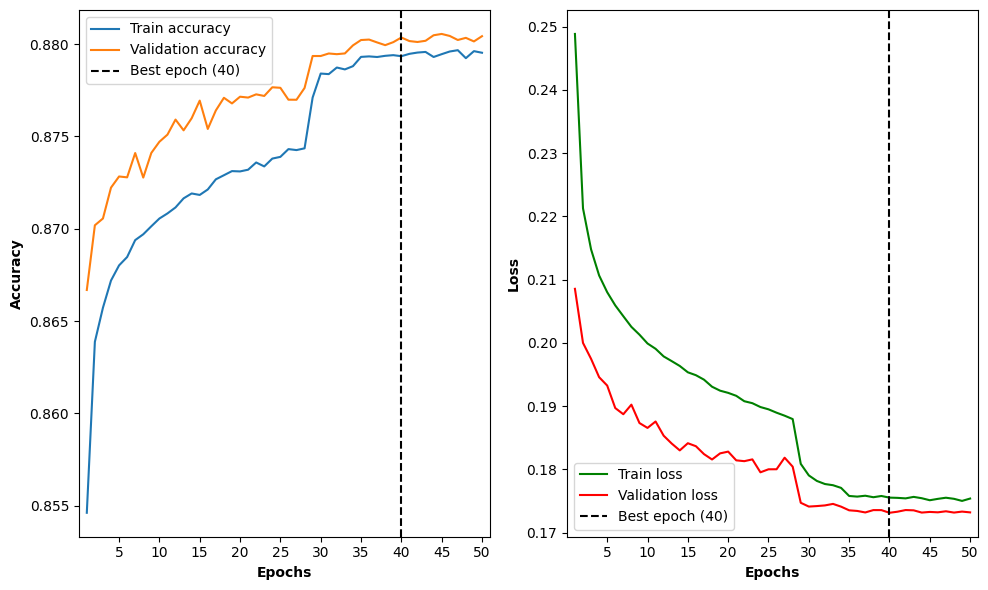

In [140]:
epochs = np.arange(1, len(train_accs) + 1)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs, label='Train accuracy')
plt.plot(epochs, val_accs,   label='Validation accuracy')
plt.axvline(x=best_epoch, color='k', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xticks(np.arange(0, len(train_accs) + 1, 5))
plt.margins(x=0.02)                  
plt.legend()
plt.xlabel('Epochs', fontweight="bold")
plt.ylabel('Accuracy', fontweight="bold")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train loss',      color='green')
plt.plot(epochs, val_losses,   label='Validation loss', color='red')
plt.axvline(x=best_epoch, color='k', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xticks(np.arange(0, len(train_accs) + 1, 5))
plt.margins(x=0.02)                 
plt.legend()
plt.xlabel('Epochs', fontweight="bold")
plt.ylabel('Loss', fontweight="bold")

plt.tight_layout()
plt.savefig(
    './refined_figures/pytorch_training_history.jpg',
    format='jpeg', dpi=300, bbox_inches='tight'
)
plt.show()

In [139]:
# Evaluate the best model
model.load_state_dict(best_model_state)
model.eval()

HybridCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
  (deconv2): ConvTranspose2d(32, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc_drivers

In [52]:
# Function for model evaluation
def evaluate_model(model, data_loader):
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for windows_batch, drivers_batch, targets_batch in data_loader:
            windows_batch = windows_batch.to(device)
            drivers_batch = drivers_batch.to(device)
            
            outputs = model(windows_batch, drivers_batch)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets_batch.cpu().numpy())
    
    # Calculate metrics
    conf_mat = confusion_matrix(all_targets, all_predictions)
    overall_accuracy = accuracy_score(all_targets, all_predictions)
    kappa = cohen_kappa_score(all_targets, all_predictions)
    class_report = classification_report(all_targets, all_predictions)
    
    return conf_mat, overall_accuracy, kappa, class_report

In [53]:
conf_mat, overall_accuracy, kappa, class_report = evaluate_model(model, test_loader)

In [54]:
# Print evaluation results
print("\n===== Best model evaluation =====")
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Cohen's Kappa Coefficient: {kappa:.4f}")
print("\nConfusion Matrix:")
print(conf_mat)
print("\nClassification Report:")
print(class_report)


===== Best model evaluation =====
Overall Accuracy: 0.8804
Cohen's Kappa Coefficient: 0.8464

Confusion Matrix:
[[84452   914  1470  3183   853     3     0    10   313]
 [ 1674 11134    84   345     3     0     0     0    75]
 [ 1875   107 85454  1226  4000   191     0    40     8]
 [ 6489   569  3786 12497   391     0     0     0    14]
 [  819     0  4010   148 54372  1810    22   124   101]
 [   22     0   221     1  2121 26523     3   194     0]
 [    0     0     0     0     5     4   201     3     0]
 [   13     0    73     4   144   299     1  1985    31]
 [  366   157     4     5    71     0     0    17  6252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     91198
           1       0.86      0.84      0.85     13315
           2       0.90      0.92      0.91     92901
           3       0.72      0.53      0.61     23746
           4       0.88      0.89      0.88     61406
           5       0.92 

### Plotting confusion matrix 

In [55]:
# Normalize confusion matrix
conf_mat_norm = conf_mat.astype('float') / conf_mat.sum(axis=1)[:, np.newaxis]
print("\nNormalized Confusion Matrix (row-wise):")
for i in range(len(conf_mat_norm)):
    for j in range(len(conf_mat_norm[i])):
        print(f"{conf_mat_norm[i][j]:.2f}", end="\t")
    print()  


Normalized Confusion Matrix (row-wise):
0.93	0.01	0.02	0.03	0.01	0.00	0.00	0.00	0.00	
0.13	0.84	0.01	0.03	0.00	0.00	0.00	0.00	0.01	
0.02	0.00	0.92	0.01	0.04	0.00	0.00	0.00	0.00	
0.27	0.02	0.16	0.53	0.02	0.00	0.00	0.00	0.00	
0.01	0.00	0.07	0.00	0.89	0.03	0.00	0.00	0.00	
0.00	0.00	0.01	0.00	0.07	0.91	0.00	0.01	0.00	
0.00	0.00	0.00	0.00	0.02	0.02	0.94	0.01	0.00	
0.01	0.00	0.03	0.00	0.06	0.12	0.00	0.78	0.01	
0.05	0.02	0.00	0.00	0.01	0.00	0.00	0.00	0.91	


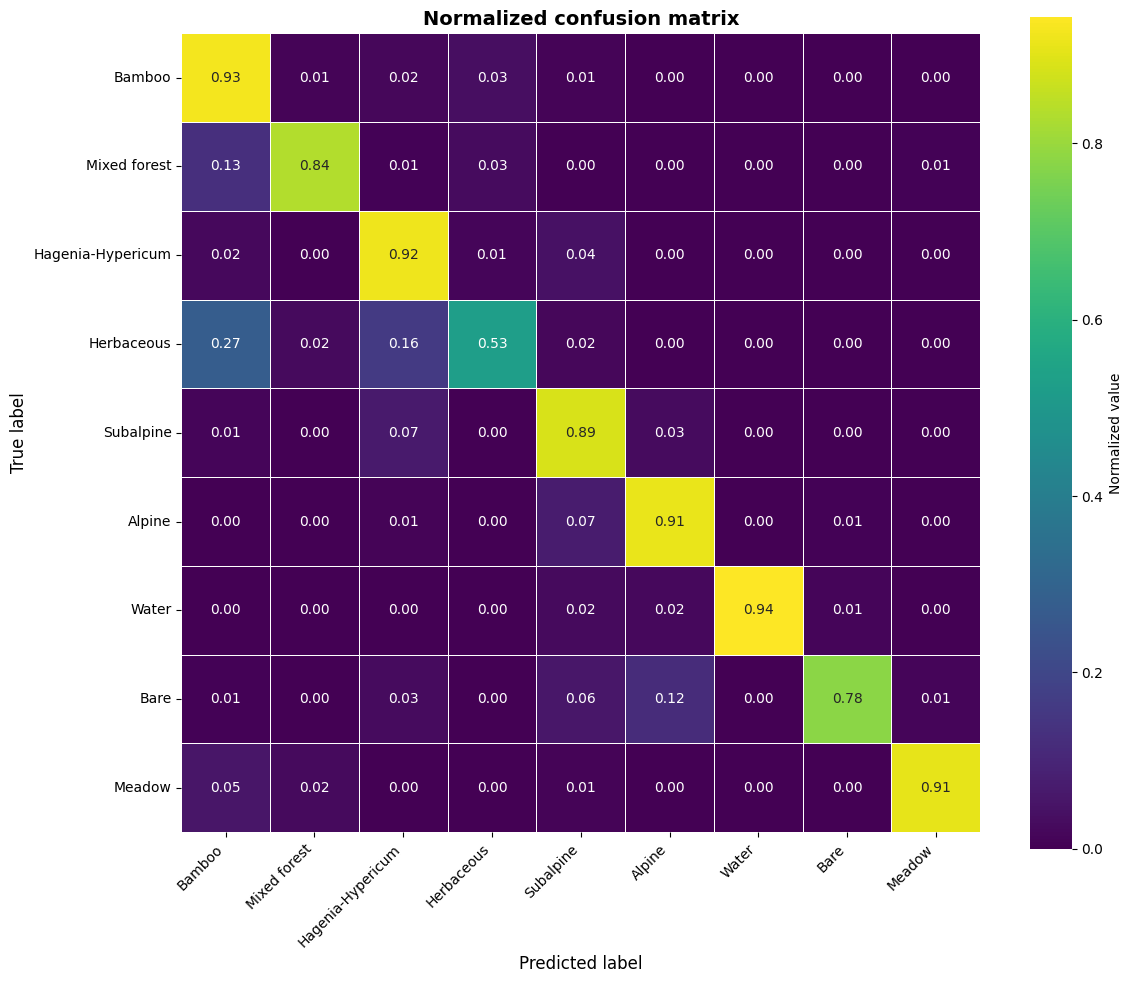

In [56]:
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    conf_mat_norm, 
    annot=True, 
    fmt='.2f',
    cmap='viridis',
    cbar_kws={'label': 'Normalized value'},
    linewidths=.5,
    square=True
)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.title('Normalized confusion matrix', fontsize=14, fontweight='bold')
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_yticklabels(class_labels, rotation=0)
plt.tight_layout()
plt.savefig('./refined_figures/confusion_matrix_best_model_focal_loss.jpg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

### Save best model

In [57]:
torch.save({
    'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'val_loss': best_val_loss,
    'val_acc': best_val_acc,
}, 'best_fcn_model_pytorch.pth')
print("Best model saved to 'best_fcn_model_pytorch.pth'")

Best model saved to 'best_fcn_model_pytorch.pth'


### Define loading function to use the best model 

In [58]:
def load_best_model(model, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with validation accuracy: {checkpoint['val_acc']:.4f}")
    return model

In [59]:
best_model = HybridCNN(window_size=4, driver_features=driver_features.shape[1], num_classes=9)
best_model = load_best_model(best_model, 'best_fcn_model_pytorch.pth')
best_model.to(device)

Loaded model from epoch 40 with validation accuracy: 0.8804


HybridCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
  (deconv2): ConvTranspose2d(32, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc_drivers

### Predict and visualize future land cover

In [60]:
def predict_landcover(model, scaler, landcover, static_drivers, dynamic_drivers, window_size=4, device="cpu"):
    model.eval()
    
    # Ensure static and dynamic drivers are NumPy arrays
    static_drivers = np.array(static_drivers)
    dynamic_drivers = np.array(dynamic_drivers)
    
    rows, cols = landcover.shape
    pad_size = window_size
    predicted_raster = np.zeros_like(landcover)

    padded_landcover = np.pad(landcover, pad_size, mode='reflect')
    
    with torch.no_grad():
        for i in range(rows):
            for j in range(cols):
                if landcover[i, j] == 0:
                    continue

                # Check for NaN values in drivers
                if np.any(np.isnan(dynamic_drivers[:, i, j])) or np.any(np.isnan(static_drivers[:, i, j])):
                    continue                                        

                # Extract window
                window = padded_landcover[i:i + 2*window_size + 1, j:j + 2*window_size + 1]
                window = window.reshape(1, 1, 2*window_size + 1, 2*window_size + 1)  # Shape for Conv2D: (batch, channels, height, width)
                
                # Get drivers
                static_values = static_drivers[:, i, j]
                dynamic_values = dynamic_drivers[:, i, j]
                
                # Combine drivers and scale
                combined_drivers = np.concatenate([static_values, dynamic_values]).reshape(1, -1)
                scaled_drivers = scaler.transform(combined_drivers)
                
                # Convert to tensors
                window_tensor = torch.FloatTensor(window).to(device)
                drivers_tensor = torch.FloatTensor(scaled_drivers).to(device)
                
                # Forward pass
                output = model(window_tensor, drivers_tensor)
                prediction = torch.argmax(output, dim=1).item() + 1  
                
                predicted_raster[i, j] = prediction
    
    return predicted_raster

In [61]:
landcover_2024_ann= predict_landcover(best_model, scaler, landcover_2019, static_drivers, bioclim_2024)

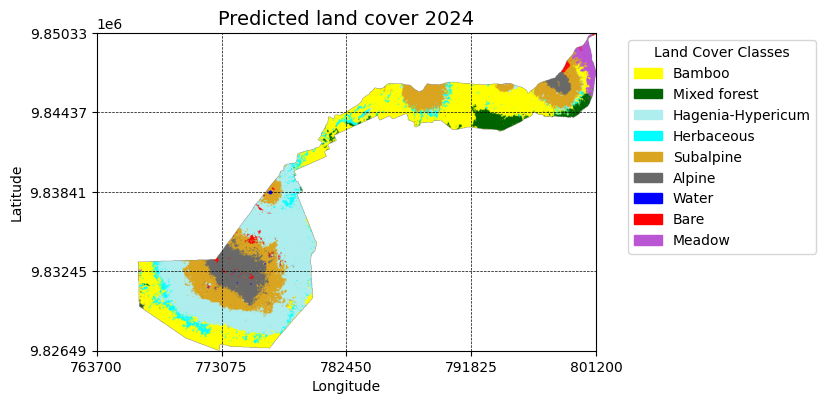

In [62]:
visualize_raster(landcover_2024_ann, "Predicted land cover 2024", class_labels, extent_2024)

In [63]:
landcover_2029_ann = predict_landcover(best_model, scaler, landcover_2024_ann, static_drivers, bioclim_2029)

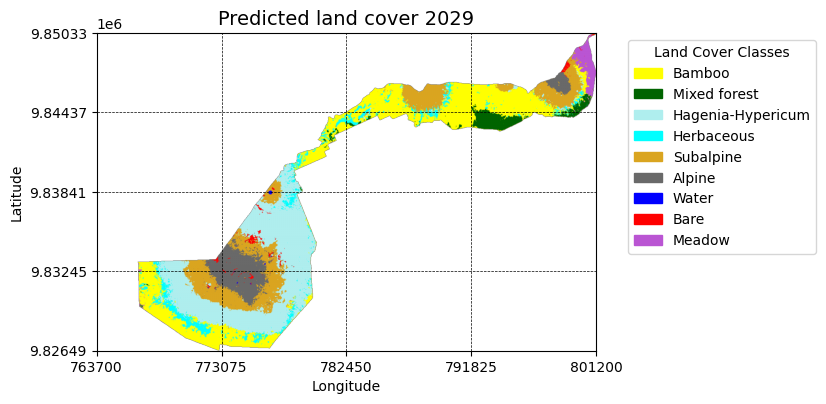

In [64]:
visualize_raster(landcover_2029_ann, "Predicted land cover 2029", class_labels, extent_2024)

In [65]:
landcover_2034_ann = predict_landcover(best_model, scaler, landcover_2029_ann, static_drivers, bioclim_2034)

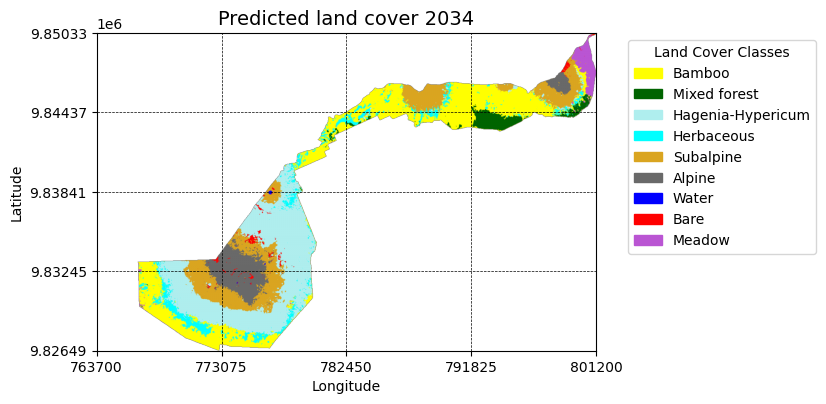

In [66]:
visualize_raster(landcover_2034_ann, "Predicted land cover 2034", class_labels, extent_2024)

In [67]:
landcover_2039_ann = predict_landcover(best_model, scaler, landcover_2034_ann, static_drivers, bioclim_2039)

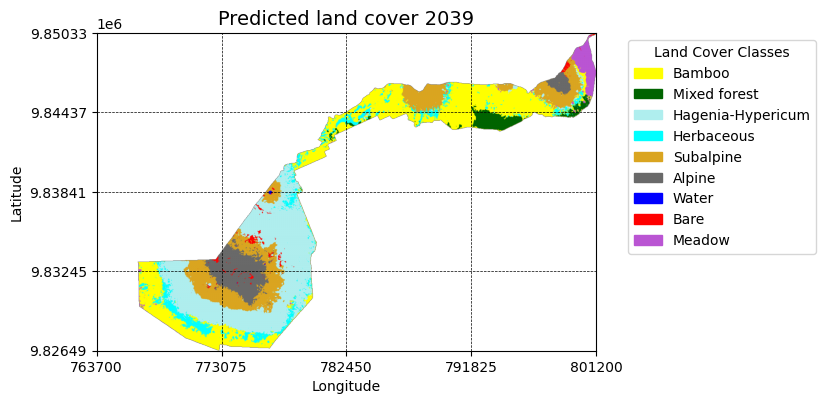

In [68]:
visualize_raster(landcover_2039_ann, "Predicted land cover 2039", class_labels, extent_2024)

In [69]:
landcover_2044_ann = predict_landcover(best_model, scaler, landcover_2039_ann, static_drivers, bioclim_2044)

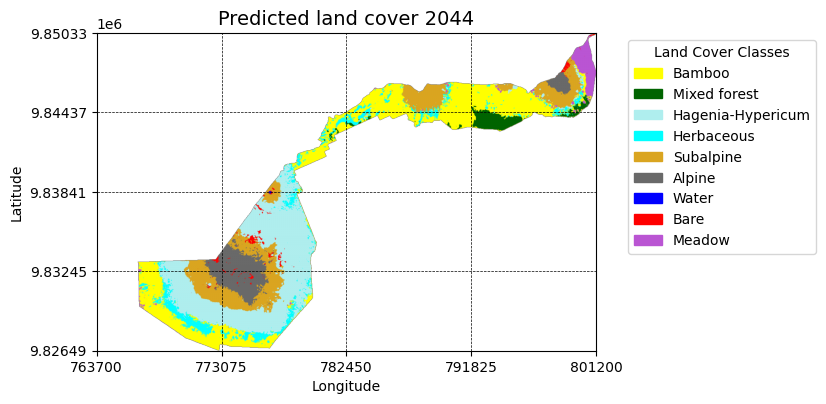

In [70]:
visualize_raster(landcover_2044_ann, "Predicted land cover 2044", class_labels, extent_2024)

In [71]:
landcover_2049_ann = predict_landcover(best_model, scaler, landcover_2044_ann, static_drivers, bioclim_2049)

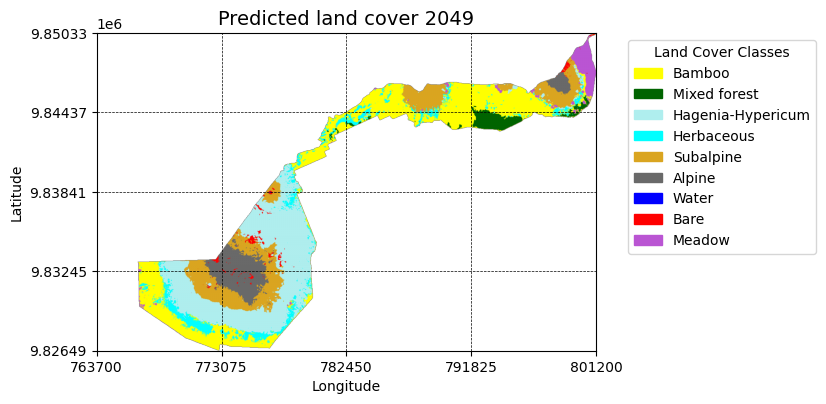

In [72]:
visualize_raster(landcover_2049_ann, "Predicted land cover 2049", class_labels, extent_2024)

### Compute the area of each class 

In [79]:
# Define class mapping: numerical values -> class labels
class_mapping = {i + 1: class_labels[i] for i in range(len(class_labels))}

In [80]:
def calculate_area_stats(raster, meta, class_mapping):
    unique, counts = np.unique(raster, return_counts=True)

    # Convert pixel counts to area (sq km)
    pixel_area = (meta['transform'][0] ** 2) / 1e6 
    areas = counts * pixel_area

    # Create DataFrame
    stats = pd.DataFrame({"Class": unique, "Area (sq km)": areas})
    
    # Filter out zero-class (unclassified areas)
    stats = stats[stats["Class"] > 0]

    # Map numeric class values to class labels
    stats["class_labels"] = stats["Class"].map(class_mapping)

    # Ensure all defined classes exist in the DataFrame (avoid missing labels)
    all_classes_df = pd.DataFrame({"class_labels": list(class_mapping.values())})
    stats = all_classes_df.merge(stats, on="class_labels", how="left").fillna(0)

    # Final formatting
    stats = stats[["class_labels", "Area (sq km)"]].set_index("class_labels")
    
    return stats

In [81]:
# Define the years to process
years = [2019, 2024, 2024_1, 2029, 2034, 2039, 2044, 2049]
landcover_maps = {
    2019: landcover_2019,
    2024: landcover_2024,
    2024_1: landcover_2024_ann,
    2029: landcover_2029_ann,
    2034: landcover_2034_ann,
    2039: landcover_2039_ann,
    2044: landcover_2044_ann,
    2049: landcover_2049_ann
}

In [82]:
def calculate_filtered_area(landcover, meta):
    unique_classes = np.unique(landcover)  # Get unique class values from raster
    valid_classes = [c for c in unique_classes if c > 0 and c in class_mapping]  # Ignore 0 and ensure valid mapping

    # Convert numeric class values to their respective labels
    class_names = [class_mapping[c] for c in valid_classes]

    return calculate_area_stats(landcover, meta, class_mapping)

In [83]:
# Compute area stats while applying the fix
area_stats = {year: calculate_filtered_area(landcover_maps[year], meta_2019) for year in years}

In [84]:
# Ensure all area data has proper column names before merging
for year in years:
    area_stats[year] = area_stats[year].rename(columns={"Area (sq km)": f"area_{year}"})

In [85]:
# Start with one year's data to initialize final_df
final_df = area_stats[years[0]].copy()
final_df.reset_index(inplace=True)  
final_df

,class_labels,area_2019
0,Bamboo,48.6548
1,Mixed forest,7.9191
2,Hagenia-Hypericum,46.9118
3,Herbaceous,6.8108
4,Subalpine,33.2353
5,Alpine,14.6020
6,Water,0.1110
7,Bare,1.1432
8,Meadow,3.0721


In [86]:
# Merge all years' data
for year in years[1:]:
    final_df = final_df.merge(area_stats[year], on="class_labels", how="outer")

In [87]:
# Ensure all missing values are set to zero (for years where a class had no area)
final_df.fillna(0, inplace=True)

In [88]:
# Compute percentage change for each period
for i in range(1, len(years)):  # Start from second year
    year = years[i]
    prev_year = years[i - 1]

    # Ensure both years exist in the DataFrame
    if f"area_{prev_year}" not in final_df.columns or f"area_{year}" not in final_df.columns:
        print(f"Skipping {prev_year} → {year}, missing data")
        continue  # Skip if missing

    # Avoid divide-by-zero errors
    valid_mask = final_df[f"area_{prev_year}"] > 0  
    final_df[f"percent_change_{prev_year}_{year}"] = 0  # Default value

    # Compute percentage change
    final_df.loc[valid_mask, f"percent_change_{prev_year}_{year}"] = (
        (final_df.loc[valid_mask, f"area_{year}"] - final_df.loc[valid_mask, f"area_{prev_year}"]) /
        final_df.loc[valid_mask, f"area_{prev_year}"] * 100
    ).round(2)

In [89]:
final_df

,class_labels,area_2019,area_2024,area_20241,area_2029,area_2034,area_2039,area_2044,area_2049,percent_change_2019_2024,percent_change_2024_20241,percent_change_20241_2029,percent_change_2029_2034,percent_change_2034_2039,percent_change_2039_2044,percent_change_2044_2049
0,Alpine,14.6020,14.6061,14.4181,14.2253,14.0667,13.9284,13.8148,13.7225,0.03,-1.29,-1.34,-1.11,-0.98,-0.82,-0.67
1,Bamboo,48.6548,46.7271,47.9968,47.5617,47.1465,46.9233,46.9204,47.3197,-3.96,2.72,-0.91,-0.87,-0.47,-0.01,0.85
2,Bare,1.1432,1.3703,1.1945,1.2895,1.3770,1.4511,1.5063,1.5619,19.87,-12.83,7.95,6.79,5.38,3.80,3.69
3,Hagenia-Hypericum,46.9118,46.4057,47.4405,47.3603,47.2859,47.2485,47.2056,47.1444,-1.08,2.23,-0.17,-0.16,-0.08,-0.09,-0.13
4,Herbaceous,6.8108,11.9466,8.6608,10.3099,11.5575,12.3891,12.8199,12.7401,75.41,-27.50,19.04,12.10,7.20,3.48,-0.62
5,Meadow,3.0721,3.6326,3.3834,3.8074,4.1368,4.4501,4.8012,5.1896,18.24,-6.86,12.53,8.65,7.57,7.89,8.09
6,Mixed forest,7.9191,6.7032,6.4998,6.0173,5.7094,5.4551,5.2346,5.0387,-15.35,-3.03,-7.42,-5.12,-4.45,-4.04,-3.74
7,Subalpine,33.2353,30.9603,30.9347,29.9650,29.2760,28.7343,28.3077,27.9176,-6.85,-0.08,-3.13,-2.30,-1.85,-1.48,-1.38
8,Water,0.1110,0.1082,0.1144,0.1066,0.0872,0.0631,0.0325,0.0085,-2.52,5.73,-6.82,-18.20,-27.64,-48.49,-73.85


### Save the results 

In [1]:
# Save to CSV
output_file = os.path.join(output_directory, "vnp_landcover_area_changes_2019_2049.csv")
final_df.to_csv(output_file, index=False)

print(f"File saved: {output_file}")

In [91]:
# Save predicted raster
def save_raster(output_path, raster, meta):
    meta.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(raster.astype(rasterio.uint8), 1)

In [92]:
save_raster(os.path.join(output_directory, "vnp_lc_2024_ann.tif"), landcover_2024_ann, meta_2019)
save_raster(os.path.join(output_directory, "vnp_lc_2029_ann.tif"), landcover_2029_ann, meta_2019)
save_raster(os.path.join(output_directory, "vnp_lc_2034_ann.tif"), landcover_2034_ann, meta_2019)
save_raster(os.path.join(output_directory, "vnp_lc_2039_ann.tif"), landcover_2039_ann, meta_2019)
save_raster(os.path.join(output_directory, "vnp_lc_2044_ann.tif"), landcover_2044_ann, meta_2019)
save_raster(os.path.join(output_directory, "vnp_lc_2049_ann.tif"), landcover_2049_ann, meta_2019)

### Computing the feature importance

In [93]:
def compute_feature_importance(
    model, scaler, landcover, static_drivers, dynamic_drivers,
    window_size=4,
    device="cpu",
    n_repeats=3,
    sample_frac=0.2,
    random_state=42
):
    feature_names = [
        "Slope",
        "Elevation",
        "Isothermality",
        "Temperature Seasonality",
        "Precipitation Seasonality",
        "Precipitation of Coldest Quarter"
    ]

    model.eval()
    rng = np.random.default_rng(random_state)

    static_drivers  = np.array(static_drivers)
    dynamic_drivers = np.array(dynamic_drivers)
    rows, cols = landcover.shape
    n_static = static_drivers.shape[0]  
    n_dynamic = dynamic_drivers.shape[0]  
    n_features = n_static + n_dynamic      

    # Valid pixels
    valid_pixels = [
        (i, j)
        for i in range(rows)
        for j in range(cols)
        if landcover[i, j] != 0
        and not np.any(np.isnan(static_drivers[:, i, j]))
        and not np.any(np.isnan(dynamic_drivers[:, i, j]))
    ]
    n_sample = max(1, int(len(valid_pixels) * sample_frac))
    sampled  = [valid_pixels[k] for k in rng.choice(len(valid_pixels), n_sample, replace=False)]
    print(f"  Sampled {n_sample} / {len(valid_pixels)} valid pixels")

    pad_size = window_size
    padded_landcover = np.pad(landcover, pad_size, mode='reflect')

    # Predict a set of pixels
    def predict_pixels(pixels, static_drv, dynamic_drv):
        preds = []
        with torch.no_grad():
            for i, j in pixels:
                window = padded_landcover[i:i + 2*window_size+1,
                                          j:j + 2*window_size+1]
                window = window.reshape(1, 1, 2*window_size+1, 2*window_size+1)

                combined = np.concatenate([
                    static_drv[:, i, j],
                    dynamic_drv[:, i, j]
                ]).reshape(1, -1)
                scaled = scaler.transform(combined)

                wt  = torch.FloatTensor(window).to(device)
                dt  = torch.FloatTensor(scaled).to(device)
                out = model(wt, dt)
                preds.append(torch.argmax(out, dim=1).item())
        return np.array(preds)

    # Baseline
    baseline_preds = predict_pixels(sampled, static_drivers, dynamic_drivers)

    # Permute each feature
    importances = np.zeros((n_features, n_repeats))

    for feat_idx in range(n_features):
        is_static = feat_idx < n_static
        for rep in range(n_repeats):
            static_perm  = static_drivers.copy()
            dynamic_perm = dynamic_drivers.copy()

            if is_static:
                flat = static_perm[feat_idx].ravel().copy()
                rng.shuffle(flat)
                static_perm[feat_idx] = flat.reshape(rows, cols)
            else:
                dyn_idx = feat_idx - n_static
                flat = dynamic_perm[dyn_idx].ravel().copy()
                rng.shuffle(flat)
                dynamic_perm[dyn_idx] = flat.reshape(rows, cols)

            permuted_preds = predict_pixels(sampled, static_perm, dynamic_perm)
            importances[feat_idx, rep] = np.mean(permuted_preds != baseline_preds)

    # Results DataFrame
    imp_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": importances.mean(axis=1),
        "Std":        importances.std(axis=1)
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    return imp_df

In [94]:
# Compute year by year importance feature
print("Computing feature importance — 2024")
imp_2024 = compute_feature_importance(best_model, scaler, landcover_2019, static_drivers, bioclim_2024)
imp_2024["Year"] = 2024

print("Computing feature importance — 2029")
imp_2029 = compute_feature_importance(best_model, scaler, landcover_2024_ann, static_drivers, bioclim_2029)
imp_2029["Year"] = 2029

print("Computing feature importance — 2034")
imp_2034 = compute_feature_importance(best_model, scaler, landcover_2029_ann, static_drivers, bioclim_2034)
imp_2034["Year"] = 2034

print("Computing feature importance — 2039")
imp_2039 = compute_feature_importance(best_model, scaler, landcover_2034_ann, static_drivers, bioclim_2039)
imp_2039["Year"] = 2039

print("Computing feature importance — 2044")
imp_2044 = compute_feature_importance(best_model, scaler, landcover_2039_ann, static_drivers, bioclim_2044)
imp_2044["Year"] = 2044

print("Computing feature importance — 2049")
imp_2049 = compute_feature_importance(best_model, scaler, landcover_2044_ann, static_drivers, bioclim_2049)
imp_2049["Year"] = 2049

Computing feature importance — 2024
  Sampled 321286 / 1606430 valid pixels
Computing feature importance — 2029
  Sampled 321286 / 1606430 valid pixels
Computing feature importance — 2034
  Sampled 321286 / 1606430 valid pixels
Computing feature importance — 2039
  Sampled 321286 / 1606430 valid pixels
Computing feature importance — 2044
  Sampled 321286 / 1606430 valid pixels
Computing feature importance — 2049
  Sampled 321286 / 1606430 valid pixels


In [95]:
all_importances = pd.concat(
    [imp_2024, imp_2029, imp_2034, imp_2039, imp_2044, imp_2049],
    ignore_index=True
)

In [96]:
all_importances.to_csv("feature_importance_2024_2049.csv", index=False)

### Visualizing importance with heatmap

In [128]:
def plot_heatmap(all_importances):
    features = [
        "Slope", "Elevation", "Isothermality", "Temperature Seasonality",
        "Precipitation Seasonality", "Precipitation of Coldest Quarter"
    ]

    pivot = all_importances.pivot_table(
        index="Feature", columns="Year", values="Importance"
    ).reindex(features).round(2)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(
        pivot, ax=ax,
        cmap="YlOrRd", annot=True, fmt=".3f",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Importance", "shrink": 0.8}
    )
    ax.set_title("", fontsize=13, pad=12)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("")
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig("./refined_figures/heatmap_importance.jpg", format = "jpeg", dpi=300, bbox_inches="tight")
    plt.show()

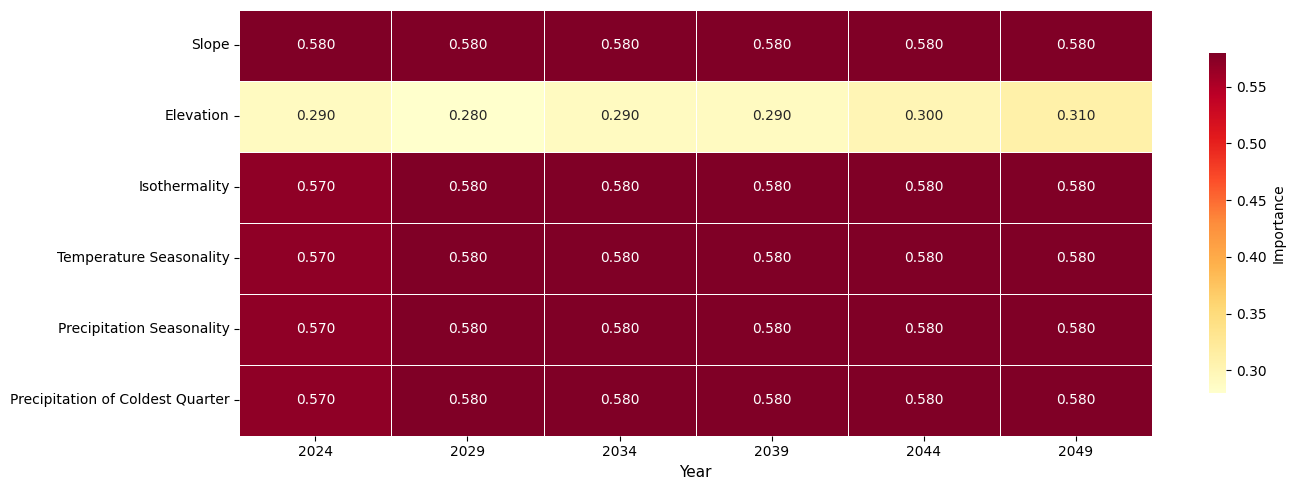

In [129]:
plot_heatmap(all_importances)

### Visualizing importance with bars

In [120]:
def plot_grouped_bar(all_importances):
    years    = sorted(all_importances["Year"].unique())
    features = [
        "Slope", "Elevation", "Isothermality", "Temperature Seasonality",
        "Precipitation Seasonality", "Precipitation of Coldest Quarter"
    ]
    palette  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

    fig, ax = plt.subplots(figsize=(12, 6))
    x       = np.arange(len(years))
    n_feat  = len(features)
    width   = 0.15
    offsets = np.linspace(-(n_feat - 1) / 2 * width, (n_feat - 1) / 2 * width, n_feat)

    for idx, (feat, color) in enumerate(zip(features, palette)):
        subset = all_importances[all_importances["Feature"] == feat].sort_values("Year")
        ax.bar(
            x + offsets[idx],
            subset["Importance"],
            width=width,
            yerr=subset["Std"],
            label=feat,
            color=color,
            edgecolor="white",
            capsize=3,
            alpha=0.85
        )

    ax.set_xticks(x)
    ax.set_xticklabels(years, fontsize=10)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Importance", fontsize=11)
    ax.set_title("", fontsize=13)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("./refined_figures/grouped_bar_importance.jpg", format = "jpeg", dpi=300, bbox_inches="tight")
    plt.show()

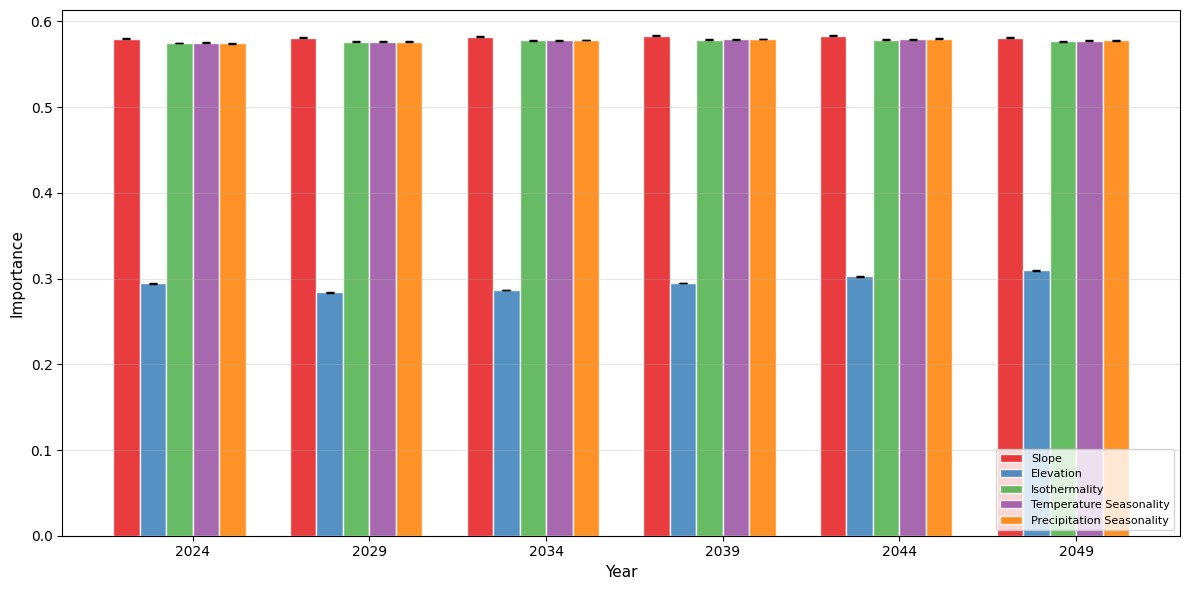

In [121]:
plot_grouped_bar(all_importances)

### Visualizing importance with trend lines

In [136]:
def plot_trend_line(all_importances):
    years    = sorted(all_importances["Year"].unique())
    features = [
        "Slope", "Elevation", "Isothermality", "Temperature Seasonality",
        "Precipitation Seasonality", "Precipitation of Coldest Quarter"
    ]
    palette = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    axes = axes.flatten()

    for ax, feat, color in zip(axes, features, palette):
        subset = all_importances[all_importances["Feature"] == feat].sort_values("Year")

        ax.plot(
            subset["Year"], subset["Importance"],
            marker="o", linewidth=2, markersize=6,
            color=color
        )

        lower = (subset["Importance"] - subset["Std"]).clip(lower=1e-6)
        upper =  subset["Importance"] + subset["Std"]
        ax.fill_between(subset["Year"], lower, upper, color=color, alpha=0.15)

        ax.grid(which="major", alpha=0.4)
        ax.grid(which="minor", alpha=0.15, linestyle=":")

        ax.set_title(feat, fontsize=10, fontweight="bold", color=color)
        ax.set_xticks(years)
        ax.set_xticklabels(years, rotation=45, fontsize=8)
        ax.set_ylabel("Importance", fontsize=9)

    fig.suptitle(" ", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(
        "./refined_figures/trend_line_importance.jpg",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

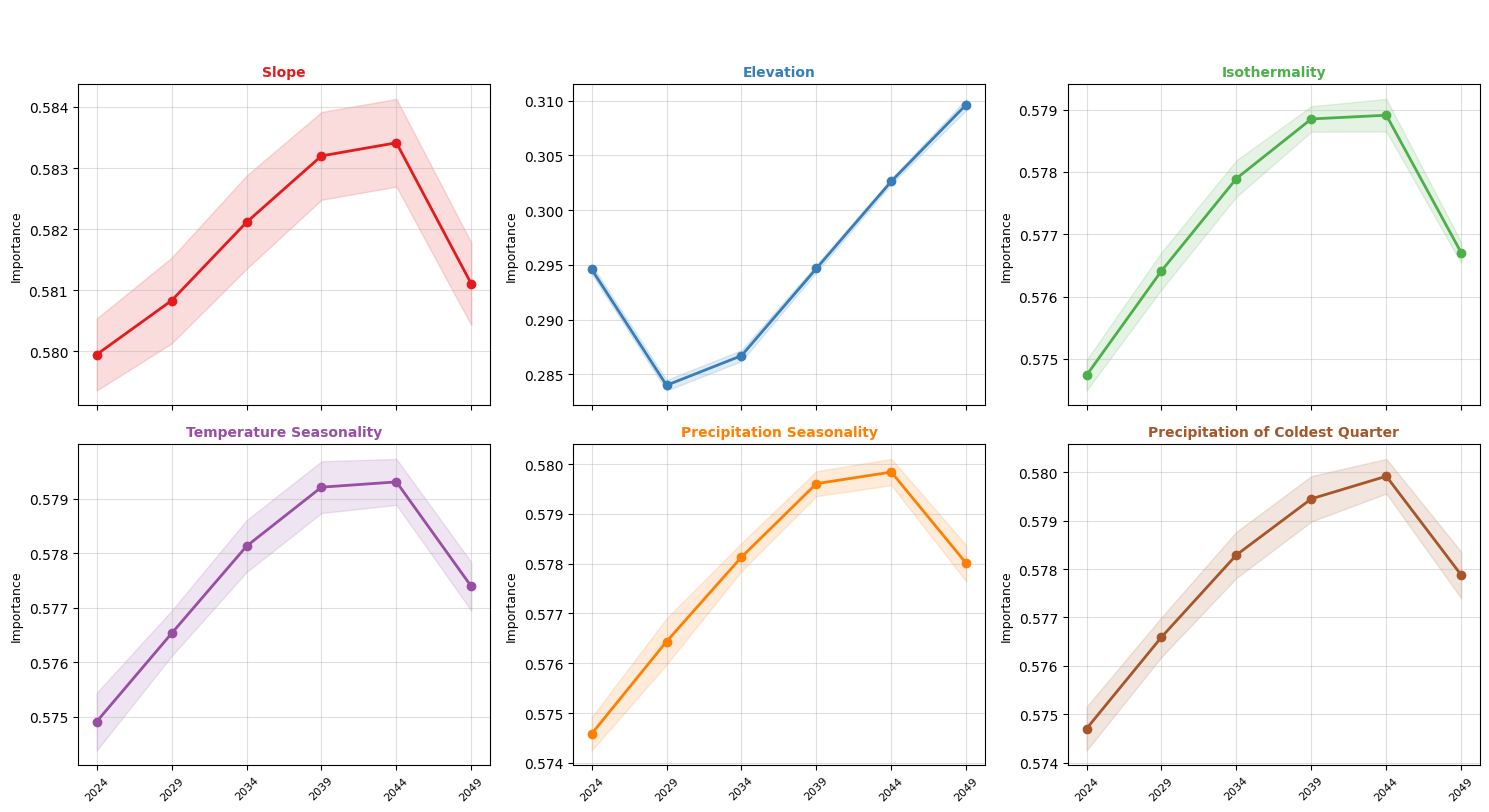

In [137]:
plot_trend_line(all_importances)

### Visualizing importance combining all figures

In [141]:
def plot_combined_importance(all_importances):

    years    = sorted(all_importances["Year"].unique())
    features = [
        "Slope",
        "Elevation",
        "Isothermality",
        "Temperature Seasonality",
        "Precipitation Seasonality",
        "Precipitation of Coldest Quarter"
    ]
    palette  = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(" ",
                 fontsize=16, fontweight="bold", y=0.98)

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.4, wspace=0.35,
                           height_ratios=[1, 1])

    # Heatmap (top-left + top-right spanning) 
    ax_heat = fig.add_subplot(gs[0, :])   # spans both columns
    pivot   = all_importances.pivot_table(
                  index="Feature", columns="Year", values="Importance"
              ).reindex(features)

    sns.heatmap(
        pivot, ax=ax_heat,
        cmap="YlOrRd", annot=True, fmt=".3f",
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Importance", "shrink": 0.8}
    )
    ax_heat.set_title("",
                      fontsize=13, pad=12)
    ax_heat.set_xlabel("Year", fontsize=11)
    ax_heat.set_ylabel("")
    ax_heat.tick_params(axis='y', rotation=0)

    # PGrouped bar chart (bottom-left)
    ax_bar  = fig.add_subplot(gs[1, 0])
    x       = np.arange(len(years))
    n_feat  = len(features)
    width   = 0.15
    offsets = np.linspace(-(n_feat-1)/2 * width, (n_feat-1)/2 * width, n_feat)

    for idx, (feat, color) in enumerate(zip(features, palette)):
        subset = all_importances[all_importances["Feature"] == feat].sort_values("Year")
        ax_bar.bar(
            x + offsets[idx],
            subset["Importance"],
            width=width,
            yerr=subset["Std"],
            label=feat,
            color=color,
            edgecolor="white",
            capsize=3,
            alpha=0.85
        )

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(years, fontsize=10)
    ax_bar.set_xlabel("Year", fontsize=11)
    ax_bar.set_ylabel("Importance", fontsize=11)
    ax_bar.set_title(" ", fontsize=13)
    ax_bar.legend(fontsize=8, loc="lower right")
    ax_bar.grid(axis="y", alpha=0.3)

    # Line plot (bottom-right)
    ax_line = fig.add_subplot(gs[1, 1])

    for feat, color in zip(features, palette):
        subset = all_importances[all_importances["Feature"] == feat].sort_values("Year")
        ax_line.plot(
            subset["Year"], subset["Importance"],
            marker="o", linewidth=2, markersize=6,
            label=feat, color=color
        )
        ax_line.fill_between(
            subset["Year"],
            subset["Importance"] - subset["Std"],
            subset["Importance"] + subset["Std"],
            color=color, alpha=0.12
        )

    ax_line.set_xticks(years)
    ax_line.set_xlabel("Year", fontsize=11)
    ax_line.set_ylabel("Importance", fontsize=11)
    ax_line.set_title(" ", fontsize=13)
    ax_line.legend(fontsize=8, loc="lower right")
    ax_line.grid(alpha=0.3)

    # plt.savefig("feature_importance_combined_2024_2049.png", dpi=150, bbox_inches="tight")
    plt.show()

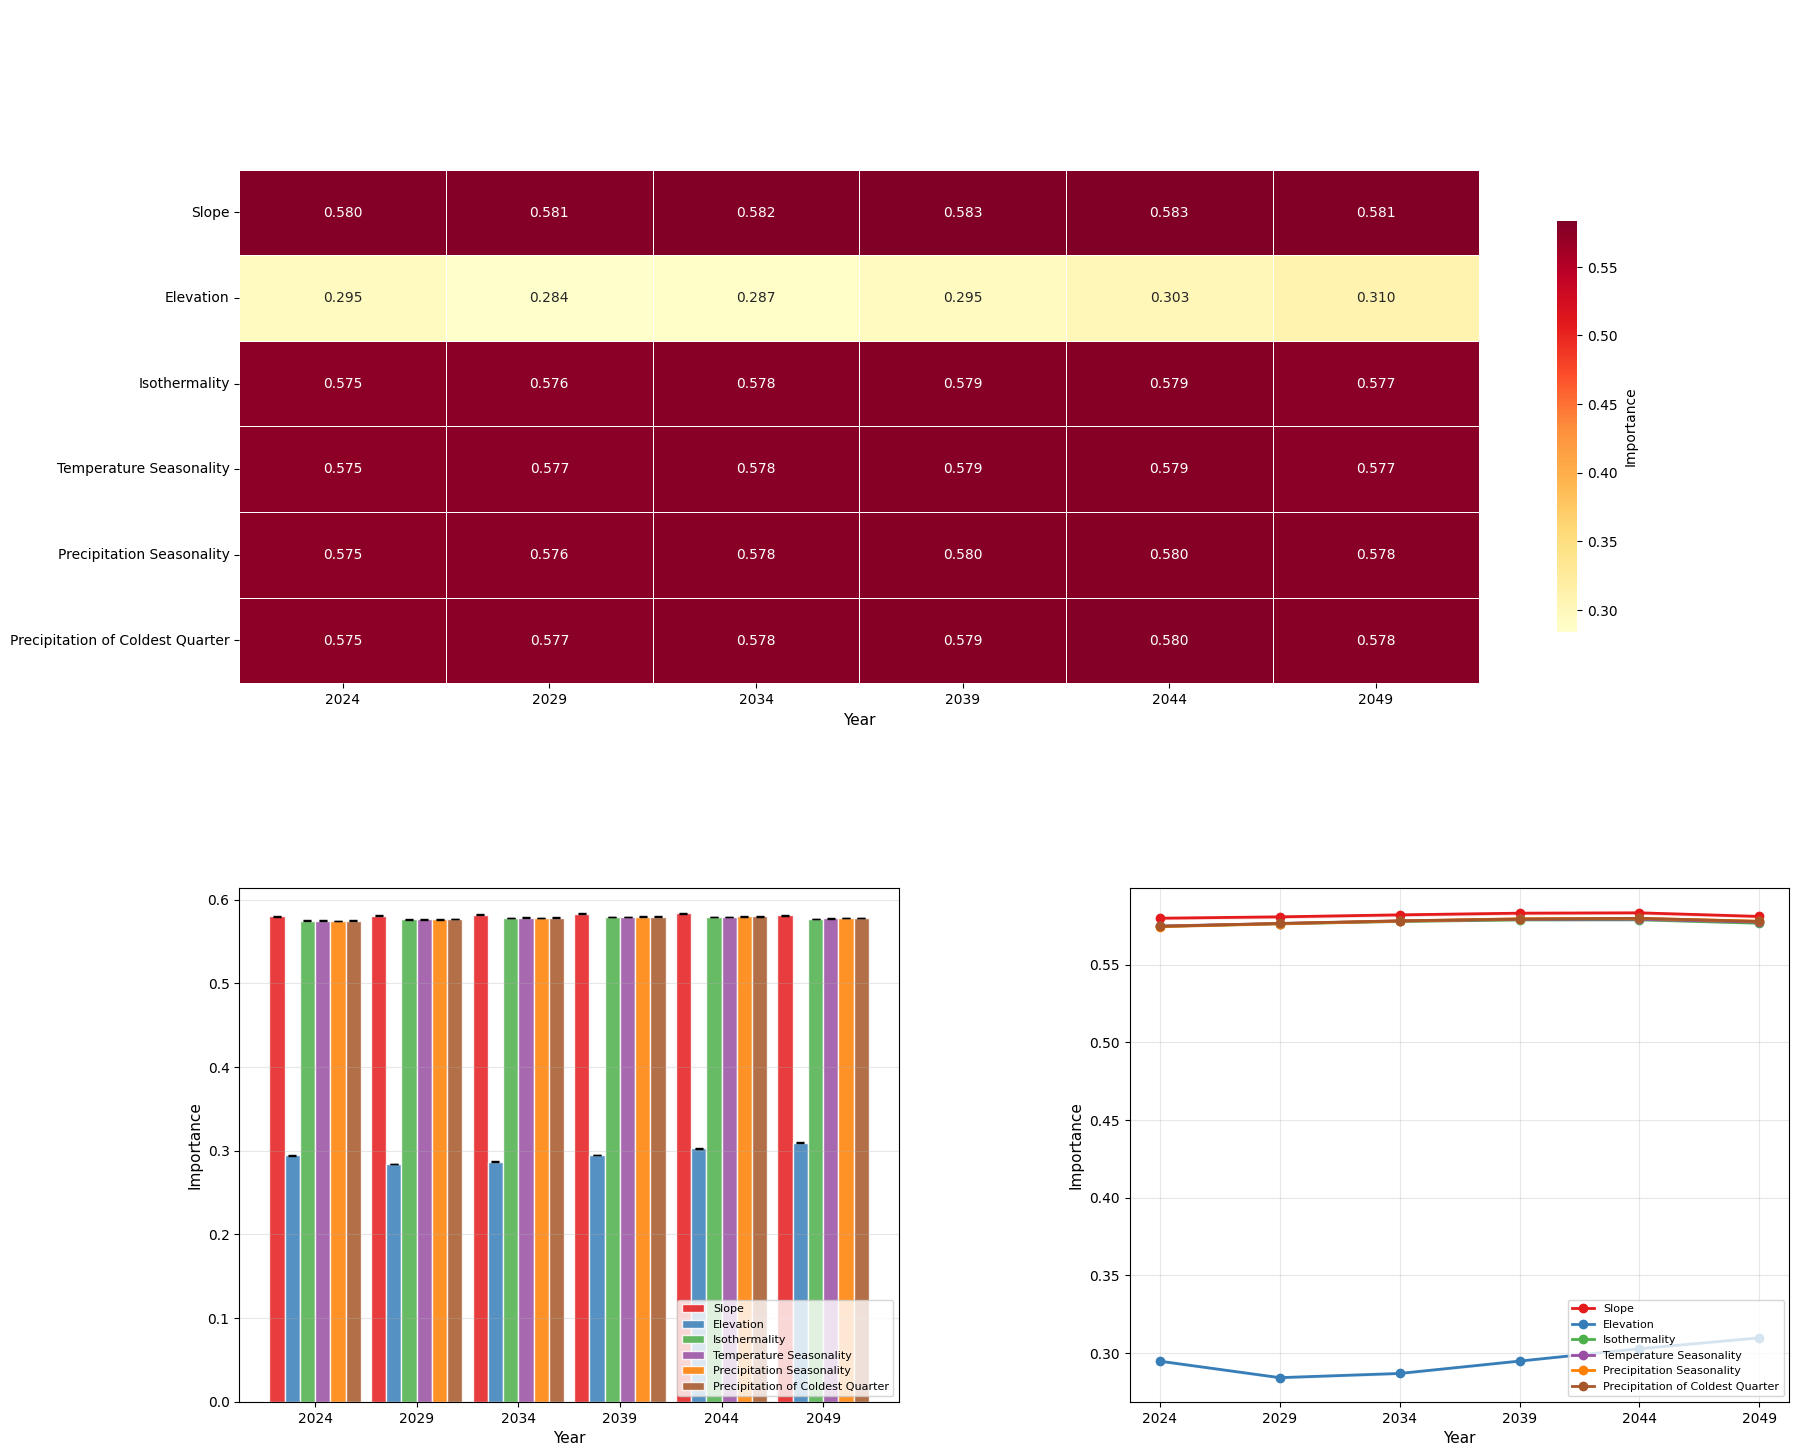

In [142]:
plot_combined_importance(all_importances)